In this assignment, I explore how combining model-free and model-based reinforcement learning can improve performance. I use the Taxi-v3 environment from Gymnasium and compare different approaches like Q-learning, Dyna-Q, Dyna-Q+, and prioritized sweeping.

The main goal is to see how adding planning and simulated experience affects how quickly the agent learns and how efficiently it uses data.

In [1]:
import gymnasium as gym
import numpy as np
import random
from collections import defaultdict
import heapq
import matplotlib.pyplot as plt

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

env_id = "Taxi-v3"

### Q-Learning (Baseline)

I start with a simple Q-learning agent as a baseline. This agent learns only from real interactions with the environment and does not use any model or planning.

This gives a good reference point to understand how much improvement we get when we later add model-based components.

In [2]:
def q_learning(
    env,
    num_episodes=300,
    alpha=0.5,
    gamma=0.99,
    epsilon=0.1,
    max_steps_per_episode=200,
    seed=0,
):
    """Pure Q-learning baseline (no planning)."""
    set_global_seed(seed)
    env = gym.make(env_id)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q_table = np.zeros((n_states, n_actions))

    def select_action(state):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        return np.argmax(Q_table[state])

    returns_per_episode = []
    cumulative_rewards = []

    running_total = 0.0

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed)
        done = False
        episode_reward = 0.0

        for _ in range(max_steps_per_episode):
            action = select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            episode_reward += reward

            # Q-learning update
            target = reward if done else reward + gamma * np.max(Q_table[next_state])
            error = target - Q_table[state, action]
            Q_table[state, action] += alpha * error

            state = next_state
            if done:
                break

        running_total += episode_reward
        returns_per_episode.append(episode_reward)
        cumulative_rewards.append(running_total)

        if (episode + 1) % 50 == 0:
            print(f"[Q-learning] Episode {episode+1}/{num_episodes} Return: {episode_reward}")

    env.close()
    return Q_table, np.array(returns_per_episode), np.array(cumulative_rewards)

### Model Learning

To enable planning, I create a simple tabular model that stores transitions as (state, action) → (reward, next state).

Each time the agent takes a step, the model is updated. I also keep track of predecessor states, which helps later when implementing prioritized sweeping.

In [3]:
class TabularModel:
    """
    Deterministic tabular model:
    Stores transitions as (state, action) -> (reward, next_state)
    Also keeps track of predecessors for prioritized sweeping.
    """
    def __init__(self):
        self.transitions = {}
        self.seen_pairs = set()
        self.prev_map = defaultdict(set)

    def update(self, state, action, reward, next_state):
        """Update model with observed transition."""
        self.transitions[(state, action)] = (reward, next_state)
        self.seen_pairs.add((state, action))
        self.prev_map[next_state].add((state, action, reward))

    def sample(self):
        """Uniformly sample a stored transition."""
        if len(self.seen_pairs) == 0:
            return None
        s, a = random.choice(list(self.seen_pairs))
        r, s_next = self.transitions[(s, a)]
        return s, a, r, s_next

    def predecessors(self, state):
        """Get all predecessor (s, a, r) leading to given state."""
        return list(self.prev_map[state])

### Dyna-Q

Dyna-Q builds on Q-learning by adding planning. After each real step in the environment, the agent performs additional updates using simulated experiences from the model.

This helps the agent learn faster since it can reuse past experiences instead of waiting for new ones.

In [4]:
def dyna_q(
    env,
    num_episodes=300,
    alpha=0.5,
    gamma=0.99,
    epsilon=0.1,
    n_planning=10,
    kappa=0.001,
    use_dyna_q_plus=False,
    dynamic_change_step=None,
    max_steps=200,
    seed=0,
):
    """
    Dyna-Q / Dyna-Q+ with optional exploration bonus and optional
    dynamic environment change trigger.
    """
    set_global_seed(seed)
    env = gym.make(env_id)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    model = TabularModel()

    time_tracker = defaultdict(lambda: 0)
    global_step = 0

    def policy(state):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(Q[state]))

    ep_returns = []
    cum_returns = []
    running_total = 0.0

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed)
        done = False
        total_reward = 0.0

        for _ in range(max_steps):
            global_step += 1

            if dynamic_change_step is not None and global_step == dynamic_change_step:
                print(f"*** Environment change at step {global_step} ***")

            # update time since visit
            for key in list(time_tracker.keys()):
                time_tracker[key] += 1

            action = policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # Direct RL update
            target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (target - Q[state, action])

            # Model update
            model.update(state, action, reward, next_state)
            time_tracker[(state, action)] = 0

            # Planning updates
            for _ in range(n_planning):
                sample = model.sample()
                if sample is None:
                    break

                s_sim, a_sim, r_sim, s_next_sim = sample

                bonus = 0.0
                if use_dyna_q_plus:
                    tau = time_tracker[(s_sim, a_sim)]
                    bonus = kappa * np.sqrt(tau)

                sim_target = r_sim + bonus
                if not done:
                    sim_target += gamma * np.max(Q[s_next_sim])

                Q[s_sim, a_sim] += alpha * (sim_target - Q[s_sim, a_sim])

            state = next_state
            if done:
                break

        running_total += total_reward
        ep_returns.append(total_reward)
        cum_returns.append(running_total)

        if (ep + 1) % 50 == 0:
            tag = "Dyna-Q+" if use_dyna_q_plus else "Dyna-Q"
            print(f"[{tag} n={n_planning}] Episode {ep+1}/{num_episodes} Return: {total_reward}")

    env.close()
    return Q, np.array(ep_returns), np.array(cum_returns)

### Prioritized Sweeping

Instead of picking past experiences randomly, prioritized sweeping focuses on the most important updates.

It uses a priority queue to update state–action pairs that have the largest expected impact, making planning more efficient and targeted.

In [5]:
def dyna_q_prioritized_sweeping(
    env,
    num_episodes=300,
    alpha=0.5,
    gamma=0.99,
    epsilon=0.1,
    n_planning=10,
    theta=0.01,
    max_steps=200,
    seed=0,
):
    """
    Dyna-Q with prioritized sweeping.
    theta: minimum priority threshold.
    """
    set_global_seed(seed)
    env = gym.make(env_id)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    model = TabularModel()

    pq = []  # ( -priority, state, action )

    def policy(state):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(Q[state]))

    def maybe_push(state, action, reward, next_state):
        """Push to priority queue if TD error is large enough."""
        target = reward + gamma * np.max(Q[next_state])
        error = target - Q[state, action]
        prio = abs(error)

        if prio > theta:
            heapq.heappush(pq, (-prio, state, action))

    ep_returns = []
    cum_returns = []
    total = 0.0

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed)
        done = False
        total_reward = 0.0

        for _ in range(max_steps):
            action = policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            total_reward += reward

            # Direct RL update
            target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (target - Q[state, action])

            # Model update
            model.update(state, action, reward, next_state)

            # Push current transition
            maybe_push(state, action, reward, next_state)

            # Planning phase
            for _ in range(n_planning):
                if not pq:
                    break

                _, s_p, a_p = heapq.heappop(pq)
                r_p, s_next_p = model.transitions[(s_p, a_p)]

                target_p = r_p + gamma * np.max(Q[s_next_p])
                Q[s_p, a_p] += alpha * (target_p - Q[s_p, a_p])

                # Update predecessors
                for (s_prev, a_prev, r_prev) in model.predecessors(s_p):
                    maybe_push(s_prev, a_prev, r_prev, s_p)

            state = next_state
            if done:
                break

        total += total_reward
        ep_returns.append(total_reward)
        cum_returns.append(total)

        if (ep + 1) % 50 == 0:
            print(f"[Prioritized Sweeping] Episode {ep+1}/{num_episodes} Return: {total_reward}")

    env.close()
    return Q, np.array(ep_returns), np.array(cum_returns)

### Experiment Setup

I run all methods using multiple random seeds to make the results more reliable.

The methods I compare are:
- Q-learning
- Dyna-Q (n = 5 and n = 10)
- Dyna-Q+
- Prioritized sweeping

I track episode returns and cumulative rewards to see how each method performs over time.

In [6]:
num_episodes = 300
gamma = 0.99
alpha = 0.5
epsilon = 0.1
seed_list = [0, 1, 2]

all_results = {
    "q_learning": [],
    "dyna_q_5": [],
    "dyna_q_10": [],
    "dyna_q_plus_10": [],
    "ps_10": [],
}

for s in seed_list:
    print(f"\n=== Running with seed {s} ===")

    # Q-learning (baseline)
    Q_base, r_base, c_base = q_learning(
        env_id,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        seed=s,
    )
    all_results["q_learning"].append((r_base, c_base))

    # Dyna-Q (n = 5)
    Q_d5, r_d5, c_d5 = dyna_q(
        env_id,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        n_planning=5,
        use_dyna_q_plus=False,
        seed=s,
    )
    all_results["dyna_q_5"].append((r_d5, c_d5))

    # Dyna-Q (n = 10)
    Q_d10, r_d10, c_d10 = dyna_q(
        env_id,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        n_planning=10,
        use_dyna_q_plus=False,
        seed=s,
    )
    all_results["dyna_q_10"].append((r_d10, c_d10))

    # Dyna-Q+ (n = 10)
    Q_dqp, r_dqp, c_dqp = dyna_q(
        env_id,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        n_planning=10,
        use_dyna_q_plus=True,
        kappa=0.001,
        seed=s,
    )
    all_results["dyna_q_plus_10"].append((r_dqp, c_dqp))

    # Prioritized Sweeping (n = 10)
    Q_ps, r_ps, c_ps = dyna_q_prioritized_sweeping(
        env_id,
        num_episodes=num_episodes,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        n_planning=10,
        seed=s,
    )
    all_results["ps_10"].append((r_ps, c_ps))


=== Running with seed 0 ===
[Q-learning] Episode 50/300 Return: 6.0
[Q-learning] Episode 100/300 Return: -30.0
[Q-learning] Episode 150/300 Return: -14.0
[Q-learning] Episode 200/300 Return: 4.0
[Q-learning] Episode 250/300 Return: 5.0
[Q-learning] Episode 300/300 Return: 6.0
[Dyna-Q n=5] Episode 50/300 Return: 6.0
[Dyna-Q n=5] Episode 100/300 Return: 5.0
[Dyna-Q n=5] Episode 150/300 Return: 6.0
[Dyna-Q n=5] Episode 200/300 Return: -6.0
[Dyna-Q n=5] Episode 250/300 Return: 5.0
[Dyna-Q n=5] Episode 300/300 Return: -15.0
[Dyna-Q n=10] Episode 50/300 Return: 6.0
[Dyna-Q n=10] Episode 100/300 Return: -1.0
[Dyna-Q n=10] Episode 150/300 Return: -20.0
[Dyna-Q n=10] Episode 200/300 Return: 2.0
[Dyna-Q n=10] Episode 250/300 Return: -50.0
[Dyna-Q n=10] Episode 300/300 Return: -5.0
[Dyna-Q+ n=10] Episode 50/300 Return: 6.0
[Dyna-Q+ n=10] Episode 100/300 Return: -8.0
[Dyna-Q+ n=10] Episode 150/300 Return: -23.0
[Dyna-Q+ n=10] Episode 200/300 Return: -4.0
[Dyna-Q+ n=10] Episode 250/300 Return: 1.0

### Results

To compare performance, I plot the average episode returns across runs.

These plots show how quickly each method improves and how stable the learning process is.

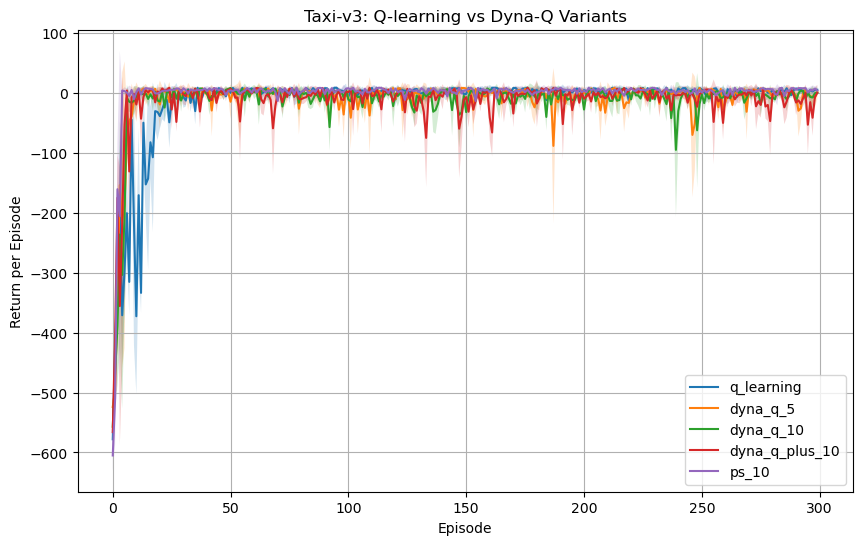

In [7]:
def plot_mean_returns(results_dict, num_episodes, title):
    plt.figure(figsize=(10, 6))

    for name, data in results_dict.items():
        # data = list of (episode_returns, cumulative_returns)
        ep_returns = np.array([item[0] for item in data])

        avg = np.mean(ep_returns, axis=0)
        std = np.std(ep_returns, axis=0)

        x = np.arange(num_episodes)
        plt.plot(x, avg, label=name)
        plt.fill_between(x, avg - std, avg + std, alpha=0.2)

    plt.xlabel("Episode")
    plt.ylabel("Return per Episode")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_mean_returns(all_results, num_episodes, "Taxi-v3: Q-learning vs Dyna-Q Variants")

### Final Thoughts

From the results, it’s clear that adding planning helps the agent learn faster.

Q-learning works, but it needs more real interactions. Dyna-Q improves efficiency by using simulated experience. Dyna-Q+ helps when the environment changes by encouraging exploration. Prioritized sweeping performs best in many cases because it focuses updates where they matter most.

Overall, model-based methods are more sample efficient, but they come with extra computation and depend on how accurate the model is.